# Lab 6 — K-Nearest Neighbours (KNN) for Classification and Regression

KNN is an **instance-based** or **lazy learning** algorithm. It doesn't actually "learn" an equation during training. Instead, it memorises the entire training dataset. When asked to make a prediction for a new, unseen data point, it looks at the $K$ closest training examples (its "neighbours") and bases its prediction on them.

* **For Classification:** It takes a majority vote among the neighbours (e.g., if 4 out of 5 closest neighbours are Malignant, predict Malignant).
* **For Regression:** It takes the average of the neighbours' target values (e.g., the average insurance cost of the 5 most similar patients).

### The Golden Rule of KNN: You MUST Scale Your Data!
Because KNN relies entirely on measuring physical distances (usually **Euclidean distance**) between data points, features with large numbers (like an insurance cost of 15,000) will completely overpower features with small numbers (like an age of 22). **Scaling is not optional for KNN; it is mandatory.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

---
## 1. KNN Classification (Breast Cancer Dataset)

Let's see if looking at neighbouring tumors is an effective way to detect cancer. We will load the Breast Cancer dataset, set Malignant = 1, and scale all
 features.

In [2]:
# 1. Load data
df = pd.read_csv("data/breast_cancer.csv")
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)
df["diagnosis"] = df["diagnosis"].map({'B': 0, 'M': 1})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale
scaler_c = StandardScaler()
X_train_scaled = scaler_c.fit_transform(X_train)
X_test_scaled = scaler_c.transform(X_test)

--- KNN Classification (K=5) ---
Accuracy: 0.9561

               precision    recall  f1-score   support

   Benign (0)       0.95      0.99      0.97        72
Malignant (1)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



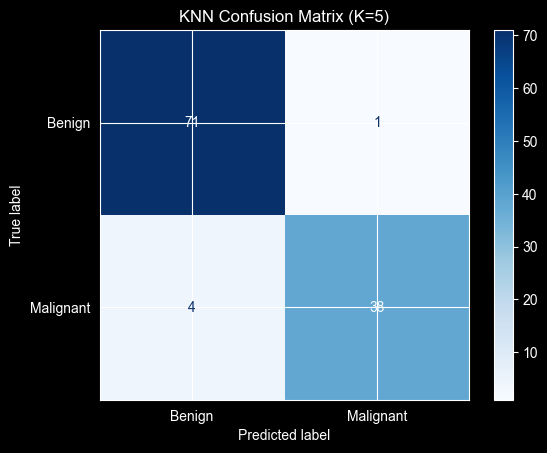

In [4]:
# Initialize KNN with K=5 (the default)
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# "Training" the model (Memorising the data)
knn_classifier.fit(X_train_scaled, y_train)

# Making predictions
y_pred_c = knn_classifier.predict(X_test_scaled)

# Evaluation
print("--- KNN Classification (K=5) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_c):.4f}\n")
print(classification_report(y_test, y_pred_c, target_names=['Benign (0)', 'Malignant (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title("KNN Confusion Matrix (K=5)")
plt.show()

---
## 2. Choosing the Right $K$ (The Elbow Method)

How did we know to choose $K=5$? We didn't! Choosing $K$ is a classic **Bias-Variance Tradeoff**:
* **Too small (e.g., $K=1$):** The model is overly sensitive to noise/outliers (High Variance, Overfitting).
* **Too large (e.g., $K=100$):** The model blends everything together and loses detail (High Bias, Underfitting).

To find the optimal $K$, we can run a loop testing different values of $K$ and plot their error rates. We look for the "elbow" of the curve—the point where the error rate drops and stabilizes.

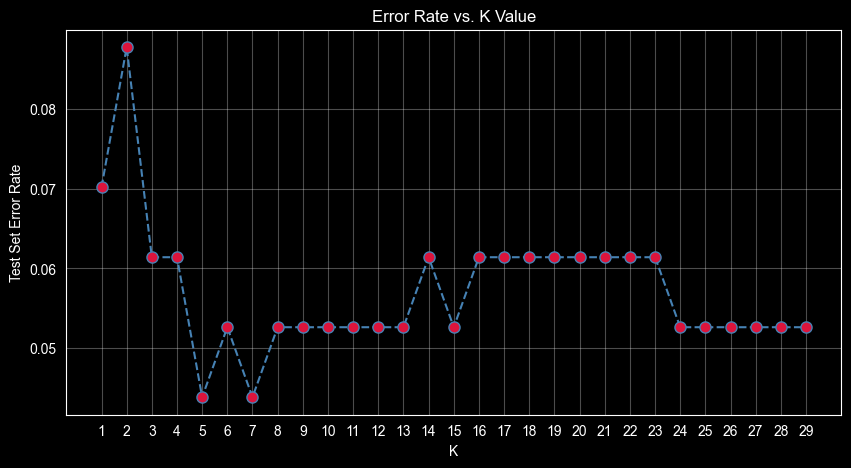

In [5]:
error_rates = []
k_values = range(1, 30) # Testing K from 1 to 29

for k in k_values:
    # Train a model for this specific K
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Predict on the test set
    pred_i = knn.predict(X_test_scaled)

    # Calculate the error rate (1 - accuracy) and append to list
    error = np.mean(pred_i != y_test)
    error_rates.append(error)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(k_values, error_rates, color='steelblue', linestyle='dashed', marker='o',
         markerfacecolor='crimson', markersize=8)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Test Set Error Rate')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

---
## 3. KNN Regression (Medical Insurance Dataset)

KNN isn't just for categories. We can use it to predict continuous numbers like insurance charges. Instead of a majority vote, **KNeighborsRegressor** finds the $K$ closest patients and calculates the average of their medical bills.

We will reload our Medical Insurance dataset, apply our `OneHotEncoder` and `StandardScaler` inside a `ColumnTransformer`, and test the model.

In [8]:
from sklearn.neighbors import KNeighborsRegressor

# 1. Load and prep data
df_ins = pd.read_csv('data/insurance.csv')
df_ins['smoker'] = df_ins['smoker'].map({'yes': 1, 'no': 0})
df_ins['sex'] = df_ins['sex'].map({'female': 1, 'male': 0})

X_reg = df_ins.drop('charges', axis=1)
y_reg = df_ins['charges']

# 2. Split data FIRST
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Setup ColumnTransformer
ohe = OneHotEncoder(drop='first', sparse_output=False)
scaler_r = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler_r, ['age', 'bmi', 'children']),
        ('cat', ohe, ['region'])
    ],
    remainder='passthrough'
)

In [9]:
# 4. Transform data
X_train_r_scaled = preprocessor.fit_transform(X_train_r)
X_test_r_scaled = preprocessor.transform(X_test_r)

# 5. Fit KNN Regressor
knn_regressor = KNeighborsRegressor(n_neighbors=7) # Using K=7 as an example
knn_regressor.fit(X_train_r_scaled, y_train_r)
y_pred_r = knn_regressor.predict(X_test_r_scaled)

# 6. Evaluate
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print("--- KNN Regression Results (K=7) ---")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

--- KNN Regression Results (K=7) ---
MAE  : 4101.73
RMSE : 6918.85
R²   : 0.6917


---
## 4. Summary: Pros and Cons of KNN

### Advantages:
1. **Simple and Intuitive:** The concept of "finding similar examples" is easy to explain to non-technical stakeholders.
2. **No Mathematical Assumptions:** Unlike Linear Regression, KNN doesn't assume the data forms a straight line. It naturally captures highly complex, non-linear relationships.
3. **No Training Time:** The `.fit()` step is essentially instantaneous because it just stores the data in memory.

### Disadvantages:
1. **Slow at Prediction (Inference):** Because it has no mathematical equation, it must calculate the distance between the new data point and *every single point in the training set* to make a single prediction. This makes it painfully slow on massive datasets.
2. **The Curse of Dimensionality:** In high-dimensional spaces (datasets with hundreds of columns), the concept of "distance" breaks down mathematically. Points become so spread out that everyone appears equally far away from everyone else.
3. **High Memory Usage:** You must carry your entire training dataset into production to make predictions.